In [ ]:
import pandas as pd
import numpy as np


In [ ]:
import pandas as pd
import numpy as np

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print(matches.shape)
print(deliveries.shape)

(1095, 11)
(260920, 8)


In [ ]:
import pandas as pd
df = pd.read_csv("deliveries.csv")
df.head()

,inning,over,batting_team,bowling_team,batsman,bowler,batsman_runs,extras
0,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,0,1
1,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0
2,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,1
3,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0
4,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,0,0


In [ ]:
import pandas as pd
df = pd.read_csv("matches.csv")
df.head()

,team1,neutralvenue,venue,date,team2,season,city,winner,event,toss_winner,toss_decision
0,Royal Challengers Bangalore,NaN,M Chinnaswamy Stadium,18-04-2008,Kolkata Knight Riders,2007/08,Bangalore,Kolkata Knight Riders,Indian Premier League,Royal Challengers Bangalore,field
1,Kings XI Punjab,NaN,"Punjab Cricket Association Stadium, Mohali",19-04-2008,Chennai Super Kings,2007/08,Chandigarh,Chennai Super Kings,Indian Premier League,Chennai Super Kings,bat
2,Delhi Daredevils,NaN,Feroz Shah Kotla,19-04-2008,Rajasthan Royals,2007/08,Delhi,Delhi Daredevils,Indian Premier League,Rajasthan Royals,bat
3,Mumbai Indians,NaN,Wankhede Stadium,20-04-2008,Royal Challengers Bangalore,2007/08,Mumbai,Royal Challengers Bangalore,Indian Premier League,Mumbai Indians,bat
4,Kolkata Knight Riders,NaN,Eden Gardens,20-04-2008,Deccan Chargers,2007/08,Kolkata,Kolkata Knight Riders,Indian Premier League,Deccan Chargers,bat


In [ ]:
df.isnull().sum()

,0
team1,0
neutralvenue,1018
venue,0
date,0
team2,0
season,0
city,51
winner,19
event,0
toss_winner,0


In [ ]:
matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)


In [ ]:
extra_cols = [
    'isWide','isNoBall','Byes','LegByes','Penalty',
    'Wides','NoBallRuns'
]

for col in extra_cols:
    if col in deliveries.columns:
        deliveries[col].fillna(0, inplace=True)


In [ ]:
for col in ['dismissal_kind']:
    if col in deliveries.columns:
        deliveries[col].fillna("None", inplace=True)



In [ ]:
extra_cols = [
    'isWide','isNoBall','Byes','LegByes',
    'Penalty','Wides','NoBallRuns'
]

for col in extra_cols:
    if col in deliveries.columns:
        deliveries[col].fillna(0, inplace=True)


In [ ]:
# Handle extras
extra_cols = [
    'isWide','isNoBall','Byes','LegByes',
    'Penalty','Wides','NoBallRuns'
]

for col in extra_cols:
    if col in deliveries.columns:
        deliveries[col].fillna(0, inplace=True)

# Handle dismissal info
if 'dismissal_kind' in deliveries.columns:
    deliveries['dismissal_kind'].fillna("None", inplace=True)


In [ ]:
# Separate numeric and categorical columns
num_cols = deliveries.select_dtypes(include=['int64','float64']).columns
cat_cols = deliveries.select_dtypes(include=['object']).columns

# Fill missing values
deliveries[num_cols] = deliveries[num_cols].fillna(0)
deliveries[cat_cols] = deliveries[cat_cols].fillna("None")


In [ ]:
print("Deliveries missing values:\n", deliveries.isnull().sum())
print("\nMatches missing values:\n", matches.isnull().sum())


Deliveries missing values:
 inning          0
over            0
batting_team    0
bowling_team    0
batsman         0
bowler          0
batsman_runs    0
extras          0
dtype: int64

Matches missing values:
 team1               0
neutralvenue     1018
venue               0
date                0
team2               0
season              0
city               51
winner             19
event               0
toss_winner         0
toss_decision       0
dtype: int64


In [ ]:
# Numeric columns
num_cols = matches.select_dtypes(include=['int64','float64']).columns
matches[num_cols] = matches[num_cols].fillna(0)

# Categorical columns
cat_cols = matches.select_dtypes(include=['object']).columns
matches[cat_cols] = matches[cat_cols].fillna("Unknown")

# Date column (if exists)
if 'dates' in matches.columns:
    matches['dates'] = pd.to_datetime(matches['dates'], errors='coerce')


In [ ]:
deliveries.to_csv("deliveries_cleaned.csv", index=False)
matches.to_csv("matches_cleaned.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


EDA

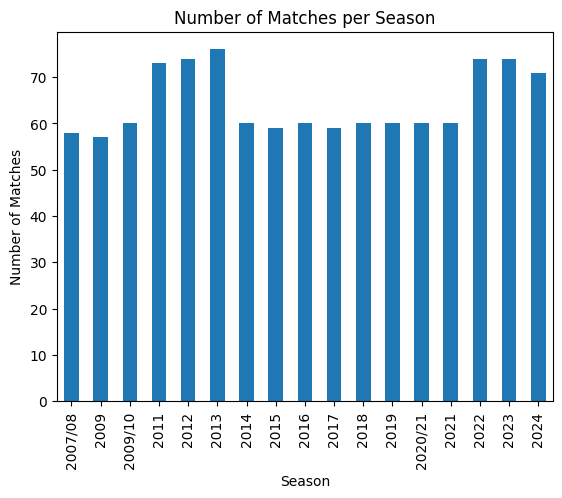

In [ ]:
import matplotlib.pyplot as plt

matches_per_season = matches['season'].value_counts().sort_index()

plt.figure()
matches_per_season.plot(kind='bar')
plt.title("Number of Matches per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()


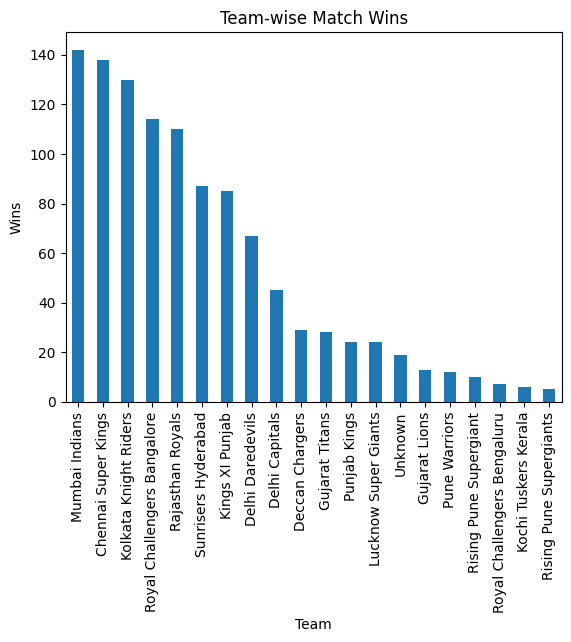

In [ ]:
team_wins = matches['winner'].value_counts()

plt.figure()
team_wins.plot(kind='bar')
plt.title("Team-wise Match Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()


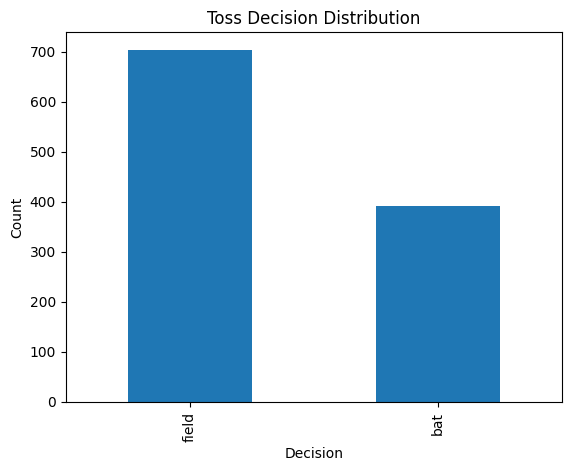

In [ ]:
plt.figure()
matches['toss_decision'].value_counts().plot(kind='bar')
plt.title("Toss Decision Distribution")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()


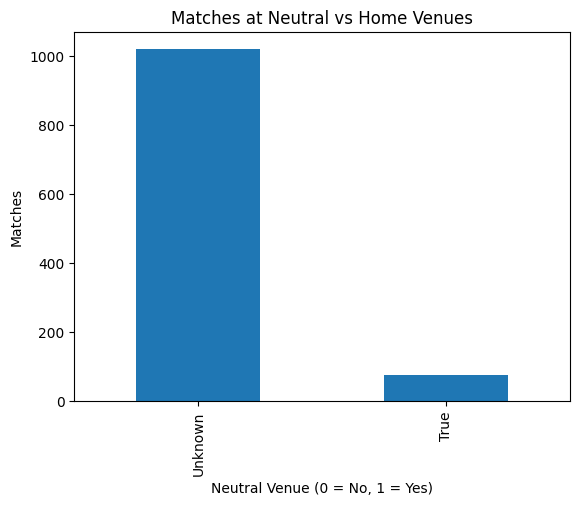

In [ ]:
plt.figure()
matches['neutralvenue'].value_counts().plot(kind='bar')
plt.title("Matches at Neutral vs Home Venues")
plt.xlabel("Neutral Venue (0 = No, 1 = Yes)")
plt.ylabel("Matches")
plt.show()


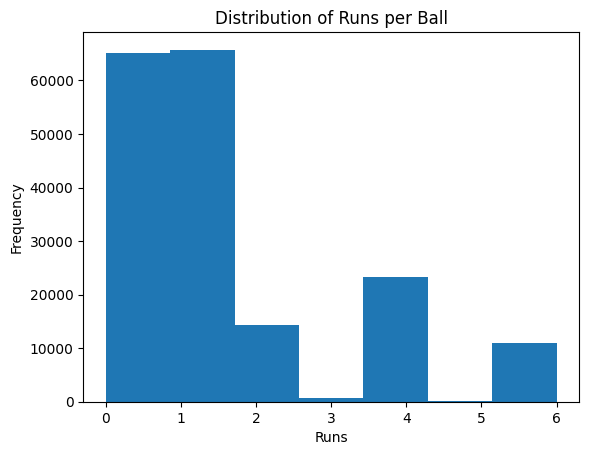

In [ ]:
plt.figure()
plt.hist(deliveries['batsman_runs'], bins=7)
plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()


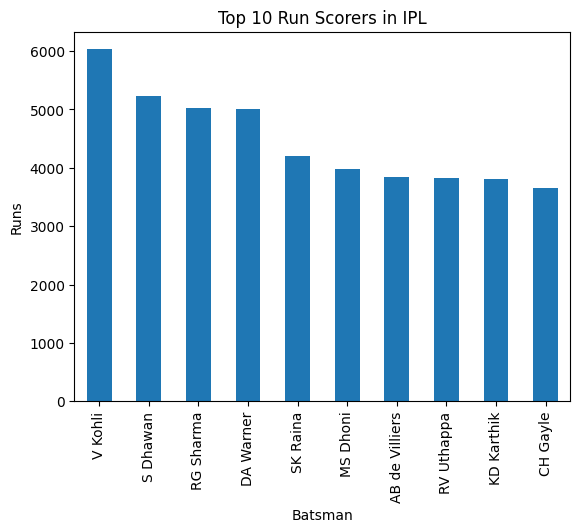

In [ ]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_batsmen.plot(kind='bar')
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()


STEP 1: MATCH-LEVEL FEATURE ENGINEERING

In [ ]:
player_runs = deliveries.groupby('batsman')['batsman_runs'].sum().reset_index()
player_runs.columns = ['batsman', 'total_runs']


In [ ]:
balls_faced = deliveries.groupby('batsman')['batsman_runs'].count().reset_index()
balls_faced.columns = ['batsman', 'balls_faced']


In [ ]:
player_runs['strike_rate'] = (player_runs['total_runs'] / balls_faced['balls_faced']) * 100


In [ ]:
boundaries = deliveries[deliveries['batsman_runs'].isin([4,6])]
boundary_count = boundaries.groupby('batsman')['batsman_runs'].count().reset_index()
boundary_count.columns = ['batsman', 'boundary_count']


In [ ]:
player_features = player_runs.merge(balls_faced, on='batsman')
player_features = player_features.merge(boundary_count, on='batsman', how='left')
player_features.fillna(0, inplace=True)


In [ ]:
y = df['winner']

In [ ]:
X = df.drop(columns=['winner'])

In [ ]:
leakage_cols = [
    'winner',
    'win_by_runs',
    'win_by_wickets',
    'player_of_match',
    'result',
    'method'
]

X = matches.drop(columns=[col for col in leakage_cols if col in matches.columns])

In [ ]:
if 'date' in X.columns:
    X['date'] = pd.to_datetime(X['date'])
    X['year'] = X['date'].dt.year
    X.drop(columns=['date'], inplace=True)

/tmp/ipython-input-444880219.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X['date'] = pd.to_datetime(X['date'])


In [ ]:
# Fill categorical missing values
for col in X.select_dtypes(include='object').columns:
    X[col].fillna(X[col].mode()[0], inplace=True)

# Fill numerical missing values
for col in X.select_dtypes(include=np.number).columns:
    X[col].fillna(X[col].mean(), inplace=True)


/tmp/ipython-input-3854558780.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mode()[0], inplace=True)
/tmp/ipython-input-3854558780.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
X.select_dtypes(include='object').columns

Index(['team1', 'neutralvenue', 'venue', 'team2', 'season', 'city', 'event',
       'toss_winner', 'toss_decision'],
      dtype='object')

In [ ]:
features = [
    'venue',
    'season',
    'toss_decision',
    'toss_winner',
    'team1',
    'team2'
]


In [ ]:
target = 'total_runs'


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in features:
    matches[col] = le.fit_transform(matches[col])


In [ ]:
target = 'winner'


In [ ]:
features = [
    'team1',
    'team2',
    'venue',
    'toss_winner',
    'toss_decision',
    'season'
]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in features + [target]:
    matches[col] = le.fit_transform(matches[col])



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = matches[features]
y = matches[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.4703196347031963


In [ ]:
matches = matches.dropna(subset=['winner'])


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ['team1','team2','venue','toss_winner','toss_decision','season','winner']:
    encoders[col] = LabelEncoder()
    matches[col] = encoders[col].fit_transform(matches[col])


In [ ]:
features = [
    'team1',
    'team2',
    'venue',
    'toss_winner',
    'toss_decision',
    'season'
]

X = matches[features]
y = matches['winner']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Clean Accuracy:", accuracy_score(y_test, pred))


Clean Accuracy: 0.5205479452054794


Milestone3_Batsman


In [ ]:
!pip install category-encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.4 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import category_encoders as ce

🎯 Target 1 – Batsman model

Predict using last 10 matches rolling average

In [ ]:
print(df.columns.tolist())


['team1', 'neutralvenue', 'venue', 'date', 'team2', 'season', 'city', 'winner', 'event', 'toss_winner', 'toss_decision']


In [ ]:
import pandas as pd

deliveries = pd.read_csv("deliveries.csv")
matches = pd.read_csv("matches.csv")


In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt


In [56]:
deliveries = pd.read_csv("deliveries.csv")
matches = pd.read_csv("matches.csv")


In [57]:
print(matches.columns.tolist())
print(deliveries.columns.tolist())


['team1', 'neutralvenue', 'venue', 'date', 'team2', 'season', 'city', 'winner', 'event', 'toss_winner', 'toss_decision']
['inning', 'over', 'batting_team', 'bowling_team', 'batsman', 'bowler', 'batsman_runs', 'extras']


In [58]:
import pandas as pd
import numpy as np


In [60]:
batsman_df = (
    deliveries.groupby(
        ["inning", "batting_team", "batsman"]
    )
    .agg(
        runs=("batsman_runs", "sum"),
        balls=("over", "count")
    )
    .reset_index()
)


In [61]:
batsman_df["match_order"] = batsman_df.groupby("batsman").cumcount()


In [62]:
batsman_df = batsman_df.sort_values(
    by=["batsman", "match_order"]
)


In [63]:
batsman_df["rolling_avg_10"] = (
    batsman_df.groupby("batsman")["runs"]
              .shift(1)                 # avoids data leakage
              .rolling(window=10, min_periods=1)
              .mean()
)


In [64]:
batsman_df["rolling_avg_10"] = batsman_df["rolling_avg_10"].fillna(0)


In [65]:
batsman_df_encoded = pd.get_dummies(
    batsman_df,
    columns=["batting_team"],
    drop_first=True
)


In [66]:
X = batsman_df_encoded.drop(
    columns=["runs", "batsman"]
)

y = batsman_df_encoded["runs"]


TRAIN TEST SPLIT

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


RandomForest

In [68]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

predict n evaluate

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))


MAE: 23.344089727414705
RMSE: 76.4726074743532
R2: 0.9601750658169088


 Baseline comparison (MANDATORY)

In [70]:
baseline_pred = batsman_df_encoded.loc[
    y_test.index, "rolling_avg_10"
]

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline R2:", r2_score(y_test, baseline_pred))


Baseline MAE: 218.3534516967707
Baseline RMSE: 414.2213343413894
Baseline R2: -0.1684447898676249


Remove leakage-prone columns

In [71]:
X = batsman_df_encoded.drop(
    columns=[
        "runs",
        "batsman",
        "balls",        # REMOVE (leakage)
        "match_order"   # REMOVE (time proxy only)
    ]
)


re-train and re-evaluate:

In [72]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))


MAE: 23.344089727414705
RMSE: 76.4726074743532
R2: 0.9601750658169088


Fix baseline scale (recommended)

In [73]:
batsman_df_encoded["rolling_avg_10"] = (
    batsman_df_encoded["rolling_avg_10"]
    .clip(lower=0, upper=150)
)


Re-evaluate baseline:

In [74]:
baseline_pred = batsman_df_encoded.loc[y_test.index, "rolling_avg_10"]

print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline R2:", r2_score(y_test, baseline_pred))


Baseline MAE: 166.03466064586755
Baseline RMSE: 384.51499408678967
Baseline R2: -0.006861718674314732
